# New Question: 
Is there a significant difference between fighters that have won title fights and fighters that have not won a title fight.
A title fight includes fights in the Ultimate Fighter, tournaments, and UFC championships.


#### IMPORTANT NOTE:
* Whenever "champion" is listed/seen in this notebook, it means a fighter that has won a title fight (non champion = no title fight win)
    * I realized that a title fight win doesn't directly mean that the fighter was a UFC champion
    * However, I only realized this at the end of this project
* This change from champion to title fight winner doesn't really change the analysis of this project too much because all of the numbers, calculations, and data remains the same
* the only thing that changes is the question itself and the interpretations of the analysis


In [508]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, levene, bootstrap
import statsmodels.api as sm

In [509]:
df = pd.read_csv("data.csv")
display(df.head())
df.info(verbose=True, show_counts=True)
df.describe()

,R_fighter,B_fighter,Referee,date,location,Winner,title_bout,weight_class,B_avg_KD,B_avg_opp_KD,...,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,B_age,R_age
0,Adrian Yanez,Gustavo Lopez,Chris Tognoni,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Bantamweight,0.000,0.0,...,0,1,0,0,Orthodox,170.18,177.80,135.0,31.0,27.0
1,Trevin Giles,Roman Dolidze,Herb Dean,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Middleweight,0.500,0.0,...,0,3,0,0,Orthodox,182.88,187.96,185.0,32.0,28.0
2,Tai Tuivasa,Harry Hunsucker,Herb Dean,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Heavyweight,NaN,NaN,...,1,3,0,0,Southpaw,187.96,190.50,264.0,32.0,28.0
3,Cheyanne Buys,Montserrat Conejo,Mark Smith,2021-03-20,"Las Vegas, Nevada, USA",Blue,False,WomenStrawweight,NaN,NaN,...,0,0,0,0,Switch,160.02,160.02,115.0,28.0,25.0
4,Marion Reneau,Macy Chiasson,Mark Smith,2021-03-20,"Las Vegas, Nevada, USA",Blue,False,WomenBantamweight,0.125,0.0,...,1,2,2,0,Orthodox,167.64,172.72,135.0,29.0,43.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6012 entries, 0 to 6011
Data columns (total 144 columns):
 #    Column                        Non-Null Count  Dtype  
---   ------                        --------------  -----  
 0    R_fighter                     6012 non-null   object 
 1    B_fighter                     6012 non-null   object 
 2    Referee                       5980 non-null   object 
 3    date                          6012 non-null   object 
 4    location                      6012 non-null   object 
 5    Winner                        6012 non-null   object 
 6    title_bout                    6012 non-null   bool   
 7    weight_class                  6012 non-null   object 
 8    B_avg_KD                      4585 non-null   float64
 9    B_avg_opp_KD                  4585 non-null   float64
 10   B_avg_SIG_STR_pct             4585 non-null   float64
 11   B_avg_opp_SIG_STR_pct         4585 non-null   float64
 12   B_avg_TD_pct                  4585 non-null   

,B_avg_KD,B_avg_opp_KD,B_avg_SIG_STR_pct,B_avg_opp_SIG_STR_pct,B_avg_TD_pct,B_avg_opp_TD_pct,B_avg_SUB_ATT,B_avg_opp_SUB_ATT,B_avg_REV,B_avg_opp_REV,...,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Height_cms,R_Reach_cms,R_Weight_lbs,B_age,R_age
count,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.00000,4585.000000,...,6012.000000,6012.000000,6012.000000,6012.000000,6012.000000,6008.000000,5606.000000,6010.000000,5840.000000,5949.000000
mean,0.247476,0.176818,0.453310,0.434290,0.292650,0.268742,0.478884,0.409276,0.15673,0.141306,...,0.306886,1.251331,1.297572,0.796241,0.069195,178.991788,183.562347,170.686356,29.293151,29.598252
std,0.378509,0.324633,0.130458,0.132618,0.273628,0.267178,0.724229,0.653826,0.34199,0.322623,...,0.619485,1.681376,1.859955,1.355801,0.273980,8.812985,10.585313,35.724626,4.063297,4.167755
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,152.400000,152.400000,115.000000,18.000000,19.000000
25%,0.000000,0.000000,0.376489,0.351045,0.031250,0.033203,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,172.720000,177.800000,145.000000,26.000000,27.000000
50%,0.015625,0.000000,0.450000,0.427500,0.250000,0.200000,0.148468,0.098389,0.00000,0.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,180.340000,182.880000,170.000000,29.000000,29.000000
75%,0.500000,0.250000,0.527500,0.510000,0.500000,0.422812,0.750000,0.531250,0.12500,0.125000,...,0.000000,2.000000,2.000000,1.000000,0.000000,185.420000,190.500000,185.000000,32.000000,32.000000
max,5.000000,3.000000,1.000000,1.000000,1.000000,1.000000,8.000000,7.000000,4.00000,3.000000,...,5.000000,10.000000,11.000000,13.000000,2.000000,210.820000,213.360000,345.000000,51.000000,47.000000


Notes:
* First need a way to see who has been a champion and who hasn't
* There isn't any missing values for the "_total_title_bouts" columns so I think it would be ok to aggregate

In [510]:
# Get only title fights
title_df = df.loc[df["title_bout"] == True]


R_win_title_df = title_df.loc[title_df["Winner"] == "Red"]  # Fights where R_fighter won the fight (became a champion)
B_win_title_df = title_df.loc[title_df["Winner"] == "Blue"] # Fights where B_fighter won the fight (became a champion)
display(R_win_title_df.head())
display(B_win_title_df.head())


# Counts the amount of times R_fighter and B_fighter have been champions.
# .count() just counts the number of rows so it doesn't matter which column is chosen.
# However, it is important to note that count() skips nulls so make sure the col has no null values.
# In this case, "Winner" has no missing values.

# For example, because R_fighter won for every row in "R_win_title_df" ("Winner" == "Red"), 
# doing groupby().count() will lead to counting the number of title fight wins for each unique fighter.
R_champ_count = R_win_title_df.groupby("R_fighter")["Winner"].count().sort_values(ascending=False)
B_champ_count = B_win_title_df.groupby("B_fighter")["Winner"].count().sort_values(ascending=False)
print(R_champ_count)
#print(B_champ_count)


# List of names of all fighters that have been champions at least once.
all_champs = pd.concat([R_champ_count, B_champ_count]).index.tolist()   # combine the 2 series vertically.
print(all_champs)
all_champs = set(all_champs)                                            # use a set to remove duplicates
print(len(all_champs))                                                  # 149 unique champions

,R_fighter,B_fighter,Referee,date,location,Winner,title_bout,weight_class,B_avg_KD,B_avg_opp_KD,...,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,B_age,R_age
26,Jan Blachowicz,Israel Adesanya,Herb Dean,2021-03-06,"Las Vegas, Nevada, USA",Red,True,LightHeavyweight,1.050781,0.000000,...,3,4,2,0,Orthodox,187.96,198.12,205.0,31.0,38.0
29,Amanda Nunes,Megan Anderson,Jason Herzog,2021-03-06,"Las Vegas, Nevada, USA",Red,True,WomenFeatherweight,0.500000,0.000000,...,3,7,2,0,Orthodox,172.72,175.26,145.0,31.0,32.0
62,Kamaru Usman,Gilbert Burns,Herb Dean,2021-02-13,"Las Vegas, Nevada, USA",Red,True,Welterweight,0.271484,0.016113,...,9,2,1,0,Switch,182.88,193.04,170.0,34.0,33.0
160,Valentina Shevchenko,Jennifer Maia,Herb Dean,2020-11-21,"Las Vegas, Nevada, USA",Red,True,WomenFlyweight,0.000000,0.000000,...,3,2,2,0,Southpaw,165.10,167.64,125.0,32.0,32.0
161,Deiveson Figueiredo,Alex Perez,Marc Goddard,2020-11-21,"Las Vegas, Nevada, USA",Red,True,Flyweight,1.031250,0.000000,...,1,4,2,0,Orthodox,165.10,172.72,125.0,28.0,32.0


,R_fighter,B_fighter,Referee,date,location,Winner,title_bout,weight_class,B_avg_KD,B_avg_opp_KD,...,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,B_age,R_age
25,Petr Yan,Aljamain Sterling,Mark Smith,2021-03-06,"Las Vegas, Nevada, USA",Blue,True,Bantamweight,0.000000,0.035156,...,3,4,0,0,Switch,170.18,170.18,135.0,31.0,28.0
251,Dominick Reyes,Jan Blachowicz,Kevin Sataki,2020-09-26,"Abu Dhabi, Abu Dhabi, United Arab Emirates",Blue,True,LightHeavyweight,0.650391,0.062500,...,1,3,1,0,Southpaw,193.04,195.58,205.0,37.0,30.0
470,Tony Ferguson,Justin Gaethje,Herb Dean,2020-05-09,"Jacksonville, Florida, USA",Blue,True,Lightweight,0.875000,0.031250,...,3,3,6,2,Orthodox,180.34,193.04,155.0,31.0,36.0
588,Max Holloway,Alexander Volkanovski,Jason Herzog,2019-12-14,"Las Vegas, Nevada, USA",Blue,True,Featherweight,0.515625,0.250000,...,5,8,2,1,Orthodox,180.34,175.26,145.0,31.0,28.0
686,Robert Whittaker,Israel Adesanya,Marc Goddard,2019-10-05,"Melbourne, Victoria, Australia",Blue,True,Middleweight,2.406250,0.000000,...,5,5,0,0,Orthodox,182.88,185.42,185.0,30.0,28.0


R_fighter
Jon Jones                13
Georges St-Pierre        12
Demetrious Johnson       11
Anderson Silva           11
Randy Couture            10
                         ..
James Wilks               1
Guy Mezger                1
Guangyou Ning             1
Glaico Franca Moreira     1
Zhang Weili               1
Name: Winner, Length: 119, dtype: int64
['Jon Jones', 'Georges St-Pierre', 'Demetrious Johnson', 'Anderson Silva', 'Randy Couture', 'Matt Hughes', 'Jose Aldo', 'Amanda Nunes', 'Ronda Rousey', 'Pat Miletich', 'Tito Ortiz', 'Joanna Jedrzejczyk', 'Tim Sylvia', 'Chuck Liddell', 'Frank Shamrock', 'BJ Penn', 'Valentina Shevchenko', 'Stipe Miocic', 'Max Holloway', 'Khabib Nurmagomedov', 'Kamaru Usman', 'Daniel Cormier', 'Renan Barao', 'Andrei Arlovski', 'Benson Henderson', 'Rich Franklin', 'Dominick Cruz', 'Henry Cejudo', 'TJ Dillashaw', 'Tyron Woodley', 'Brock Lesnar', 'Jens Pulver', 'Chris Weidman', 'Cristiane Justino', 'Frank Mir', 'Israel Adesanya', 'Robbie Lawler', 'Rashad Ev

In [511]:
# A fighter such as Nate Diaz has never been a UFC champion but was a winner of the Ultimate Fighter.
# However, in this dataset, the Ultimate fighter seems to be considered as a regular fight in the UFC.
# Due to this, I think it is difficult to identify specifically UFC champions with this dataset.
# So what I am actually testing in this project is if there is a significant difference between title fight winners and fighters that have
# not won a title fight.
# I realized this at the end of this project.
if "Nate Diaz" in all_champs:
    print("Not all UFC Champs.")

Not all UFC Champs.


In [512]:
# If the name of the fighter is in the "all_champs" list, return true.
# If not, return false.
# 2 new columns created: R_champ and B_champ
df['R_champ'] = df['R_fighter'].isin(all_champs)
df['B_champ'] = df['B_fighter'].isin(all_champs)
display(df.head())


# remove all rows with missing values
no_df = df.dropna().copy()
display(no_df)

,R_fighter,B_fighter,Referee,date,location,Winner,title_bout,weight_class,B_avg_KD,B_avg_opp_KD,...,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,B_age,R_age,R_champ,B_champ
0,Adrian Yanez,Gustavo Lopez,Chris Tognoni,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Bantamweight,0.000,0.0,...,0,0,Orthodox,170.18,177.80,135.0,31.0,27.0,False,False
1,Trevin Giles,Roman Dolidze,Herb Dean,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Middleweight,0.500,0.0,...,0,0,Orthodox,182.88,187.96,185.0,32.0,28.0,False,False
2,Tai Tuivasa,Harry Hunsucker,Herb Dean,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Heavyweight,NaN,NaN,...,0,0,Southpaw,187.96,190.50,264.0,32.0,28.0,False,False
3,Cheyanne Buys,Montserrat Conejo,Mark Smith,2021-03-20,"Las Vegas, Nevada, USA",Blue,False,WomenStrawweight,NaN,NaN,...,0,0,Switch,160.02,160.02,115.0,28.0,25.0,False,False
4,Marion Reneau,Macy Chiasson,Mark Smith,2021-03-20,"Las Vegas, Nevada, USA",Blue,False,WomenBantamweight,0.125,0.0,...,2,0,Orthodox,167.64,172.72,135.0,29.0,43.0,False,True


,R_fighter,B_fighter,Referee,date,location,Winner,title_bout,weight_class,B_avg_KD,B_avg_opp_KD,...,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,B_age,R_age,R_champ,B_champ
0,Adrian Yanez,Gustavo Lopez,Chris Tognoni,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Bantamweight,0.000000,0.000,...,0,0,Orthodox,170.18,177.80,135.0,31.0,27.0,False,False
1,Trevin Giles,Roman Dolidze,Herb Dean,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Middleweight,0.500000,0.000,...,0,0,Orthodox,182.88,187.96,185.0,32.0,28.0,False,False
4,Marion Reneau,Macy Chiasson,Mark Smith,2021-03-20,"Las Vegas, Nevada, USA",Blue,False,WomenBantamweight,0.125000,0.000,...,2,0,Orthodox,167.64,172.72,135.0,29.0,43.0,False,True
5,Leonardo Santos,Grant Dawson,Chris Tognoni,2021-03-20,"Las Vegas, Nevada, USA",Blue,False,Lightweight,0.000000,0.000,...,2,0,Orthodox,182.88,190.50,155.0,27.0,41.0,True,False
6,Song Kenan,Max Griffin,Keith Peterson,2021-03-20,"Las Vegas, Nevada, USA",Blue,False,Welterweight,0.046875,0.125,...,0,0,Orthodox,182.88,180.34,170.0,35.0,31.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5759,Tito Ortiz,Evan Tanner,John McCarthy,2001-02-23,"Atlantic City, New Jersey, USA",Red,True,LightHeavyweight,0.000000,0.000,...,1,1,Orthodox,190.50,187.96,205.0,30.0,26.0,True,True
5767,Chuck Liddell,Jeff Monson,Mario Yamasaki,2000-12-16,"Tokyo, Japan",Red,False,Middleweight,0.000000,0.000,...,0,1,Orthodox,187.96,193.04,205.0,29.0,30.0,True,False
5799,Tito Ortiz,Wanderlei Silva,John McCarthy,2000-04-14,"Tokyo, Japan",Red,True,LightHeavyweight,0.500000,0.500,...,0,1,Orthodox,190.50,187.96,205.0,23.0,25.0,True,False
5840,Jeremy Horn,Chuck Liddell,John McCarthy,1999-03-05,"Bay St. Louis, Mississippi, USA",Red,False,Middleweight,0.000000,0.000,...,0,0,Orthodox,185.42,187.96,185.0,29.0,23.0,False,True


What I want to do next:
* make sure that the stats being checked for each figher is consistent so will only record the stats for every fighters last fight
* prob better to see stats of each fighter one time so the data isn't skewed/bias 

Notes:
* seems like the total number of champions reduces from 149 -> 127
* this is most likely due to dropping the missing values from earlier
* so technically not considering every single champion

In [513]:
# set to datetime
no_df["date"] = pd.to_datetime(no_df["date"])
no_df.sort_values(by="date", ascending=False, inplace=True)  # sort by date

# 2 separate dfs for R_fighter and B_fighter. Focusing on fighters that have been champions first.
R_champ_only_df = no_df.loc[no_df["R_champ"] == True]
B_champ_only_df = no_df.loc[no_df["B_champ"] == True]
display(R_champ_only_df.head())

# getting all of the R fighters stats and also the date, weight_class
R_champ_cols = ["date"] + ["weight_class"] + R_champ_only_df.columns[R_champ_only_df.columns.str.startswith("R_")].tolist() # when you add 2 lists together, it combines
R_champ_only_df = R_champ_only_df[R_champ_cols].copy()                      # only R_fighter stats
R_champ_only_df["side"] = "Red"                                             # keeping track of red or blue fighter
display(R_champ_only_df.head())                                             # display df
R_champ_only_df.columns = R_champ_only_df.columns.str.removeprefix("R_")    # removing "R_" in the beginning of columns to combine it later

B_champ_cols = ["date"] + ["weight_class"] + B_champ_only_df.columns[B_champ_only_df.columns.str.startswith("B_")].tolist()
B_champ_only_df = B_champ_only_df[B_champ_cols].copy()
B_champ_only_df["side"] = "Blue"
display(B_champ_only_df.head())
B_champ_only_df.columns = B_champ_only_df.columns.str.removeprefix("B_")




combined_champs_df = pd.concat([R_champ_only_df, B_champ_only_df])              # combine the dfs vertically
combined_champs_df.sort_values(by="date", ascending=False, inplace=True)        # sort by date
combined_champs_df = combined_champs_df.drop_duplicates(subset=["fighter"])     
# 1. sort by date
# 2. dropping every duplicate fighter row except for the first occurrence.
# 3. bc data is sorted by date, drop_duplicates leads to the latest stats to remain for each fighter bc the df is sorted by date.

display(combined_champs_df)

,R_fighter,B_fighter,Referee,date,location,Winner,title_bout,weight_class,B_avg_KD,B_avg_opp_KD,...,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,B_age,R_age,R_champ,B_champ
5,Leonardo Santos,Grant Dawson,Chris Tognoni,2021-03-20,"Las Vegas, Nevada, USA",Blue,False,Lightweight,0.000000,0.000000,...,2,0,Orthodox,182.88,190.50,155.0,27.0,41.0,True,False
29,Amanda Nunes,Megan Anderson,Jason Herzog,2021-03-06,"Las Vegas, Nevada, USA",Red,True,WomenFeatherweight,0.500000,0.000000,...,2,0,Orthodox,172.72,175.26,145.0,31.0,32.0,True,False
26,Jan Blachowicz,Israel Adesanya,Herb Dean,2021-03-06,"Las Vegas, Nevada, USA",Red,True,LightHeavyweight,1.050781,0.000000,...,2,0,Orthodox,187.96,198.12,205.0,31.0,38.0,True,True
25,Petr Yan,Aljamain Sterling,Mark Smith,2021-03-06,"Las Vegas, Nevada, USA",Blue,True,Bantamweight,0.000000,0.035156,...,0,0,Switch,170.18,170.18,135.0,31.0,28.0,True,True
23,Dominick Cruz,Casey Kenney,Jason Herzog,2021-03-06,"Las Vegas, Nevada, USA",Red,False,Bantamweight,0.000000,0.000000,...,0,0,Orthodox,172.72,172.72,135.0,29.0,35.0,True,False


,date,weight_class,R_fighter,R_avg_KD,R_avg_opp_KD,R_avg_SIG_STR_pct,R_avg_opp_SIG_STR_pct,R_avg_TD_pct,R_avg_opp_TD_pct,R_avg_SUB_ATT,...,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,R_age,R_champ,side
5,2021-03-20,Lightweight,Leonardo Santos,0.312500,0.015625,0.565156,0.343594,0.337031,0.048906,0.039062,...,2,2,0,Orthodox,182.88,190.50,155.0,41.0,True,Red
29,2021-03-06,WomenFeatherweight,Amanda Nunes,0.251465,0.000000,0.519829,0.428234,0.633231,0.005947,1.008789,...,7,2,0,Orthodox,172.72,175.26,145.0,32.0,True,Red
26,2021-03-06,LightHeavyweight,Jan Blachowicz,0.825195,0.031250,0.456122,0.403876,0.022808,0.047681,0.017700,...,4,2,0,Orthodox,187.96,198.12,205.0,38.0,True,Red
25,2021-03-06,Bantamweight,Petr Yan,1.531250,0.062500,0.539531,0.409062,0.589688,0.017812,0.031250,...,4,0,0,Switch,170.18,170.18,135.0,28.0,True,Red
23,2021-03-06,Bantamweight,Dominick Cruz,0.125000,1.000000,0.376094,0.458750,0.119062,0.195625,0.015625,...,1,0,0,Orthodox,172.72,172.72,135.0,35.0,True,Red


,date,weight_class,B_fighter,B_avg_KD,B_avg_opp_KD,B_avg_SIG_STR_pct,B_avg_opp_SIG_STR_pct,B_avg_TD_pct,B_avg_opp_TD_pct,B_avg_SUB_ATT,...,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_Stance,B_Height_cms,B_Reach_cms,B_Weight_lbs,B_age,B_champ,side
4,2021-03-20,WomenBantamweight,Macy Chiasson,0.125000,0.000000,0.535625,0.578750,0.185000,0.166250,0.125000,...,2,1,0,Orthodox,180.34,182.88,135.0,29.0,True,Blue
26,2021-03-06,LightHeavyweight,Israel Adesanya,1.050781,0.000000,0.528477,0.420781,0.000000,0.009570,0.132812,...,4,0,0,Switch,193.04,203.20,185.0,31.0,True,Blue
25,2021-03-06,Bantamweight,Aljamain Sterling,0.000000,0.035156,0.582124,0.420787,0.034219,0.074475,1.128052,...,1,4,0,Orthodox,170.18,180.34,135.0,31.0,True,Blue
75,2021-02-06,Bantamweight,Frankie Edgar,0.001991,0.289082,0.444719,0.516684,0.141343,0.000017,0.016671,...,4,2,1,Orthodox,167.64,172.72,135.0,39.0,True,Blue
86,2021-01-23,Middleweight,Antonio Carlos Junior,0.000000,0.500000,0.402061,0.443130,0.441841,0.281494,0.259766,...,0,5,0,Orthodox,187.96,200.66,185.0,30.0,True,Blue


,date,weight_class,fighter,avg_KD,avg_opp_KD,avg_SIG_STR_pct,avg_opp_SIG_STR_pct,avg_TD_pct,avg_opp_TD_pct,avg_SUB_ATT,...,win_by_KO/TKO,win_by_Submission,win_by_TKO_Doctor_Stoppage,Stance,Height_cms,Reach_cms,Weight_lbs,age,champ,side
5,2021-03-20,Lightweight,Leonardo Santos,0.312500,0.015625,0.565156,0.343594,0.337031,0.048906,0.039062,...,2,2,0,Orthodox,182.88,190.50,155.0,41.0,True,Red
4,2021-03-20,WomenBantamweight,Macy Chiasson,0.125000,0.000000,0.535625,0.578750,0.185000,0.166250,0.125000,...,2,1,0,Orthodox,180.34,182.88,135.0,29.0,True,Blue
26,2021-03-06,LightHeavyweight,Jan Blachowicz,0.825195,0.031250,0.456122,0.403876,0.022808,0.047681,0.017700,...,4,2,0,Orthodox,187.96,198.12,205.0,38.0,True,Red
25,2021-03-06,Bantamweight,Aljamain Sterling,0.000000,0.035156,0.582124,0.420787,0.034219,0.074475,1.128052,...,1,4,0,Orthodox,170.18,180.34,135.0,31.0,True,Blue
29,2021-03-06,WomenFeatherweight,Amanda Nunes,0.251465,0.000000,0.519829,0.428234,0.633231,0.005947,1.008789,...,7,2,0,Orthodox,172.72,175.26,145.0,32.0,True,Red
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4739,2010-02-06,LightHeavyweight,Mark Coleman,0.000000,0.562500,0.509551,0.505566,0.444883,0.125000,0.103516,...,3,3,0,Orthodox,185.42,190.50,205.0,45.0,True,Blue
5094,2008-06-21,Middleweight,Evan Tanner,0.062500,1.009766,0.491013,0.438183,0.401138,0.047189,0.829254,...,4,4,1,Orthodox,182.88,187.96,185.0,37.0,True,Blue
5128,2008-04-19,Middleweight,Travis Lutter,0.062500,0.000000,0.314375,0.542500,0.487500,0.135000,0.250000,...,1,1,0,Orthodox,180.34,190.50,185.0,34.0,True,Blue
5159,2008-02-02,Heavyweight,Tim Sylvia,0.040527,0.285156,0.421221,0.600811,0.001953,0.683750,0.125000,...,5,0,0,Orthodox,203.20,203.20,265.0,31.0,True,Blue


In [514]:
# Now doing the same thing for fighters that have not been champions.
R_no_champ_df = no_df.loc[no_df["R_champ"] == False]
B_no_champ_df = no_df.loc[no_df["B_champ"] == False]

# Red and Blue side specific columns
R_no_champ_cols = ["date"] + ["weight_class"] + R_no_champ_df.columns[R_no_champ_df.columns.str.startswith("R_")].tolist()
B_no_champ_cols = ["date"] + ["weight_class"] + B_no_champ_df.columns[B_no_champ_df.columns.str.startswith("B_")].tolist()

# New red side dataframes with specific columns
R_no_champ_df = R_no_champ_df[R_no_champ_cols].copy()
R_no_champ_df["side"] = "Red"
display(R_no_champ_df.head())
R_no_champ_df.columns = R_no_champ_df.columns.str.removeprefix("R_")    # removing "R_" so later can concat the 2 dataframes

# New blue side dataframes with specific columns
B_no_champ_df = B_no_champ_df[B_no_champ_cols].copy()
B_no_champ_df["side"] = "Blue"
display(B_no_champ_df.head())
B_no_champ_df.columns = B_no_champ_df.columns.str.removeprefix("B_")    # removing "B_" so later can concat the 2 dataframes


no_champ_comb_df = pd.concat([R_no_champ_df, B_no_champ_df])
no_champ_comb_df.sort_values(by="date", ascending=False, inplace=True)  # sort by date
no_champ_comb_df = no_champ_comb_df.drop_duplicates(subset=["fighter"]) # default = "first" which means that the first occurence is kept
# again, sorting by date then dropping duplicates (keeping first row) allows us to see the latest stats of a fighter without seeing duplicates

display(no_champ_comb_df)

# No need to keep the "champ" column because every fighter in this df has not been a champion.
no_champ_comb_df = no_champ_comb_df.drop(columns="champ", inplace=False).copy()
no_champ_comb_df.info()

,date,weight_class,R_fighter,R_avg_KD,R_avg_opp_KD,R_avg_SIG_STR_pct,R_avg_opp_SIG_STR_pct,R_avg_TD_pct,R_avg_opp_TD_pct,R_avg_SUB_ATT,...,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,R_age,R_champ,side
0,2021-03-20,Bantamweight,Adrian Yanez,1.000000,0.000000,0.500000,0.460000,0.000000,0.00000,0.000000,...,1,0,0,Orthodox,170.18,177.80,135.0,27.0,False,Red
4,2021-03-20,WomenBantamweight,Marion Reneau,0.000000,0.000977,0.403076,0.554961,0.511719,0.62875,0.231445,...,2,2,0,Orthodox,167.64,172.72,135.0,43.0,False,Red
6,2021-03-20,Welterweight,Song Kenan,0.625000,0.000000,0.493125,0.430000,0.000000,0.68750,0.000000,...,3,0,0,Orthodox,182.88,180.34,170.0,31.0,False,Red
7,2021-03-20,Middleweight,Derek Brunson,0.024551,0.220703,0.515636,0.445974,0.355824,0.00000,0.000092,...,7,1,0,Southpaw,185.42,195.58,185.0,37.0,False,Red
1,2021-03-20,Middleweight,Trevin Giles,1.031250,0.062500,0.576875,0.381250,0.406250,0.11625,0.250000,...,3,0,0,Orthodox,182.88,187.96,185.0,28.0,False,Red


,date,weight_class,B_fighter,B_avg_KD,B_avg_opp_KD,B_avg_SIG_STR_pct,B_avg_opp_SIG_STR_pct,B_avg_TD_pct,B_avg_opp_TD_pct,B_avg_SUB_ATT,...,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_Stance,B_Height_cms,B_Reach_cms,B_Weight_lbs,B_age,B_champ,side
0,2021-03-20,Bantamweight,Gustavo Lopez,0.000000,0.000,0.420000,0.495000,0.330000,0.360000,0.500000,...,0,1,0,Orthodox,165.10,170.18,135.0,31.0,False,Blue
5,2021-03-20,Lightweight,Grant Dawson,0.000000,0.000,0.515000,0.473750,0.435000,0.250000,1.250000,...,0,2,0,Switch,177.80,182.88,145.0,27.0,False,Blue
6,2021-03-20,Welterweight,Max Griffin,0.046875,0.125,0.459277,0.404687,0.322188,0.068867,0.189453,...,2,0,0,Orthodox,180.34,193.04,170.0,35.0,False,Blue
7,2021-03-20,Middleweight,Kevin Holland,0.156250,0.000,0.791582,0.850586,0.269199,0.393398,0.029297,...,3,2,0,Orthodox,190.50,205.74,185.0,28.0,False,Blue
1,2021-03-20,Middleweight,Roman Dolidze,0.500000,0.000,0.660000,0.305000,0.300000,0.500000,1.500000,...,1,0,0,Orthodox,187.96,193.04,205.0,32.0,False,Blue


,date,weight_class,fighter,avg_KD,avg_opp_KD,avg_SIG_STR_pct,avg_opp_SIG_STR_pct,avg_TD_pct,avg_opp_TD_pct,avg_SUB_ATT,...,win_by_KO/TKO,win_by_Submission,win_by_TKO_Doctor_Stoppage,Stance,Height_cms,Reach_cms,Weight_lbs,age,champ,side
0,2021-03-20,Bantamweight,Adrian Yanez,1.000000,0.000000,0.500000,0.460000,0.000000,0.000000,0.000000,...,1,0,0,Orthodox,170.18,177.80,135.0,27.0,False,Red
4,2021-03-20,WomenBantamweight,Marion Reneau,0.000000,0.000977,0.403076,0.554961,0.511719,0.628750,0.231445,...,2,2,0,Orthodox,167.64,172.72,135.0,43.0,False,Red
6,2021-03-20,Welterweight,Max Griffin,0.046875,0.125000,0.459277,0.404687,0.322188,0.068867,0.189453,...,2,0,0,Orthodox,180.34,193.04,170.0,35.0,False,Blue
7,2021-03-20,Middleweight,Kevin Holland,0.156250,0.000000,0.791582,0.850586,0.269199,0.393398,0.029297,...,3,2,0,Orthodox,190.50,205.74,185.0,28.0,False,Blue
1,2021-03-20,Middleweight,Roman Dolidze,0.500000,0.000000,0.660000,0.305000,0.300000,0.500000,1.500000,...,1,0,0,Orthodox,187.96,193.04,205.0,32.0,False,Blue
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5399,2006-10-10,LightHeavyweight,Ken Shamrock,0.125000,0.000000,0.141904,0.817227,0.294678,0.202500,0.555176,...,2,4,0,Orthodox,185.42,182.88,205.0,42.0,False,Blue
5475,2006-04-15,Welterweight,Nick Thompson,0.000000,0.000000,0.440000,0.350000,1.000000,0.600000,3.000000,...,0,0,0,Orthodox,185.42,187.96,170.0,24.0,False,Blue
5487,2006-04-06,Middleweight,Trevor Prangley,0.000000,0.000000,0.597500,0.560000,0.682500,0.000000,0.500000,...,0,1,0,Orthodox,185.42,190.50,185.0,33.0,False,Blue
5550,2005-08-20,Middleweight,Matt Lindland,0.000000,0.259766,0.332529,0.247656,0.316680,0.523438,0.695312,...,3,1,0,Southpaw,182.88,187.96,185.0,35.0,False,Red


<class 'pandas.core.frame.DataFrame'>
Index: 1216 entries, 0 to 5551
Data columns (total 72 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   date                        1216 non-null   datetime64[ns]
 1   weight_class                1216 non-null   object        
 2   fighter                     1216 non-null   object        
 3   avg_KD                      1216 non-null   float64       
 4   avg_opp_KD                  1216 non-null   float64       
 5   avg_SIG_STR_pct             1216 non-null   float64       
 6   avg_opp_SIG_STR_pct         1216 non-null   float64       
 7   avg_TD_pct                  1216 non-null   float64       
 8   avg_opp_TD_pct              1216 non-null   float64       
 9   avg_SUB_ATT                 1216 non-null   float64       
 10  avg_opp_SUB_ATT             1216 non-null   float64       
 11  avg_REV                     1216 non-null   float64       
 1

Columns that I am curious to see the difference in:
* Strikes:
    * avg_HEAD_landed
    * avg_BODY_landed
    * avg_LEG_landed
    * avg_CLINCH_landed
    * win_by_KO/TKO
* Ground:
    * avg_TD_pct
    * avg_SUB_ATT
    * avg_REV
    * avg_TD_landed
    * avg_GROUND_landed
    * avg_CTRL_time(seconds)
    * win_by_Submission

,avg_TOTAL_STR_att,avg_opp_TOTAL_STR_att,win_by_KO/TKO,avg_TD_pct,avg_opp_TD_pct,avg_TD_att,avg_opp_TD_att,avg_SUB_ATT,avg_opp_SUB_ATT,avg_REV,avg_CTRL_time(seconds),win_by_Submission
avg_TOTAL_STR_att,1.000,0.713,-0.068,0.077,-0.048,0.188,0.273,-0.032,-0.156,0.018,0.221,-0.077
avg_opp_TOTAL_STR_att,0.713,1.000,-0.088,-0.021,0.076,0.147,0.296,-0.079,-0.080,-0.025,0.006,-0.065
win_by_KO/TKO,-0.068,-0.088,1.000,-0.114,-0.134,-0.152,-0.102,-0.181,-0.119,-0.105,-0.133,0.146
avg_TD_pct,0.077,-0.021,-0.114,1.000,-0.156,0.300,-0.035,0.138,0.064,0.052,0.460,0.056
avg_opp_TD_pct,-0.048,0.076,-0.134,-0.156,1.000,-0.079,0.277,0.138,0.266,0.229,-0.064,-0.015
avg_TD_att,0.188,0.147,-0.152,0.300,-0.079,1.000,-0.129,0.095,0.035,0.029,0.628,0.061
avg_opp_TD_att,0.273,0.296,-0.102,-0.035,0.277,-0.129,1.000,-0.001,0.102,0.155,-0.049,-0.118
avg_SUB_ATT,-0.032,-0.079,-0.181,0.138,0.138,0.095,-0.001,1.000,0.070,0.316,0.243,0.215
avg_opp_SUB_ATT,-0.156,-0.080,-0.119,0.064,0.266,0.035,0.102,0.070,1.000,0.196,0.130,-0.086
avg_REV,0.018,-0.025,-0.105,0.052,0.229,0.029,0.155,0.316,0.196,1.000,0.209,0.067


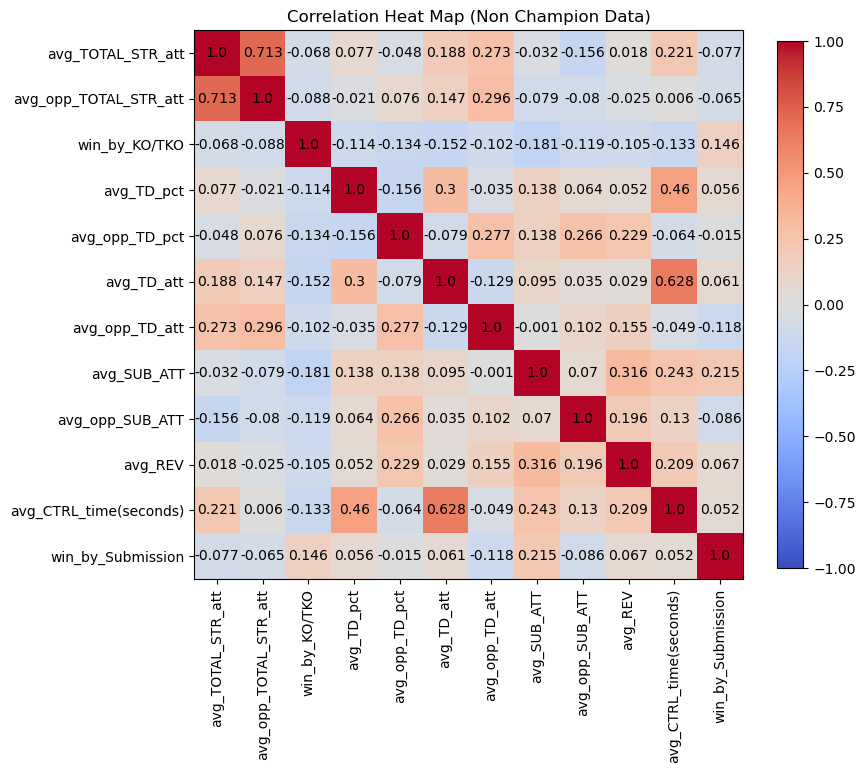

In [515]:
no_champ_curious_df = no_champ_comb_df[[
    "avg_TOTAL_STR_att", 
    "avg_opp_TOTAL_STR_att",
    "win_by_KO/TKO",
    "avg_TD_pct",
    "avg_opp_TD_pct",
    "avg_TD_att",
    "avg_opp_TD_att",
    "avg_SUB_ATT",
    "avg_opp_SUB_ATT",
    "avg_REV",
    "avg_CTRL_time(seconds)",
    "win_by_Submission"
]]
no_champ_corr_matrix = no_champ_curious_df.corr(numeric_only=True)
no_champ_corr_matrix = no_champ_corr_matrix.round(3)
display(no_champ_corr_matrix)

# Difficult to visualize every single correlation value.
# So, reduced the amount of cols to the ones seen above.
# A lot of the columns were somewhat similar so reduced to smaller subset of cols that could somewhat represent the other cols as well.




fig, ax = plt.subplots(figsize = (9,9))

# Position [0,0] is the top left in a heat map.
# Make sure to set vmin and vmax so the scale isn't automatically set. 
# Without setting the scale yourself, it may seem like negative correlation values are not significant.
hm = ax.imshow(no_champ_corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(no_champ_corr_matrix.columns)), labels=no_champ_corr_matrix.columns, rotation=90)
ax.set_yticks(range(len(no_champ_corr_matrix.columns)), labels=no_champ_corr_matrix.columns)
ax.set_title("Correlation Heat Map (Non Champion Data)")

# The reason that i and j are flipped in ax.text() is because x is the first argument.
# X is keeping track of the horizontal positions which is the same responsibility that the columns have.
# That is why j is first in ax.text(j, i, ...)
for i in range(len(no_champ_corr_matrix)):
    for j in range(len(no_champ_corr_matrix.columns)):
        text = ax.text(j, i, no_champ_corr_matrix.values[i,j], ha="center", va="center")

legend = fig.colorbar(hm, ax=ax, shrink=0.7)

fig.tight_layout()

Notes (Correlation does not automatically imply causation. Just listing my thoughts here.): 
* can see significantly larger correlations between avg_TOTAL_STR_att and [avg_HEAD_landed, avg_BODY_landed, avg_LEG_landed]
    * makes sense because more strikes will lead to more strikes landed
* avg_TD_pct and avg_CTRL_time(seconds) are slightly correlated as well
    * this also makes sense because more takedowns a fighter lands, the greater the chance for the fighter to be in control on the ground
* something that didn't make too much sense for me was the avg_SUB_ATT and win_by_Submission correlation (quite small)
    * something this might mean is that submissions are extremely difficult to do successfully

Actions:
* based on this, I think it is ok to remove avg_HEAD_landed, avg_BODY_landed, and avg_LEG_landed
* I think it would be better to add opponent columns

Notes After Action:
* added avg_opp_TOTAL_STR_att, avg_opp_TD_pct, avg_TD_att, avg_opp_TD_att, avg_opp_SUB_ATT
* large correlation between these columns: (avg_opp_TOTAL_STR_att, avg_TOTAL_STR_att), (avg_CTRL_time(seconds), avg_TD_att)

(REMEMBER: the above heat map is only representing the non champion dataframe and not the champion dataframe.)

,avg_TOTAL_STR_att,avg_opp_TOTAL_STR_att,win_by_KO/TKO,avg_TD_pct,avg_opp_TD_pct,avg_TD_att,avg_opp_TD_att,avg_SUB_ATT,avg_opp_SUB_ATT,avg_REV,avg_CTRL_time(seconds),win_by_Submission
avg_TOTAL_STR_att,1.000,0.785,-0.059,0.087,-0.014,0.300,0.242,0.031,-0.009,0.171,0.268,-0.013
avg_opp_TOTAL_STR_att,0.785,1.000,0.091,-0.076,0.130,0.167,0.377,-0.035,-0.021,0.104,0.016,-0.066
win_by_KO/TKO,-0.059,0.091,1.000,-0.211,-0.084,-0.372,-0.114,-0.238,-0.223,-0.260,-0.305,-0.027
avg_TD_pct,0.087,-0.076,-0.211,1.000,-0.113,0.436,-0.026,0.217,0.159,0.162,0.600,0.207
avg_opp_TD_pct,-0.014,0.130,-0.084,-0.113,1.000,-0.104,0.367,0.134,0.203,0.215,-0.005,-0.034
avg_TD_att,0.300,0.167,-0.372,0.436,-0.104,1.000,-0.030,0.205,0.126,0.127,0.701,0.050
avg_opp_TD_att,0.242,0.377,-0.114,-0.026,0.367,-0.030,1.000,0.172,0.082,0.192,0.034,-0.175
avg_SUB_ATT,0.031,-0.035,-0.238,0.217,0.134,0.205,0.172,1.000,0.404,0.337,0.316,0.219
avg_opp_SUB_ATT,-0.009,-0.021,-0.223,0.159,0.203,0.126,0.082,0.404,1.000,0.266,0.219,-0.024
avg_REV,0.171,0.104,-0.260,0.162,0.215,0.127,0.192,0.337,0.266,1.000,0.209,0.062


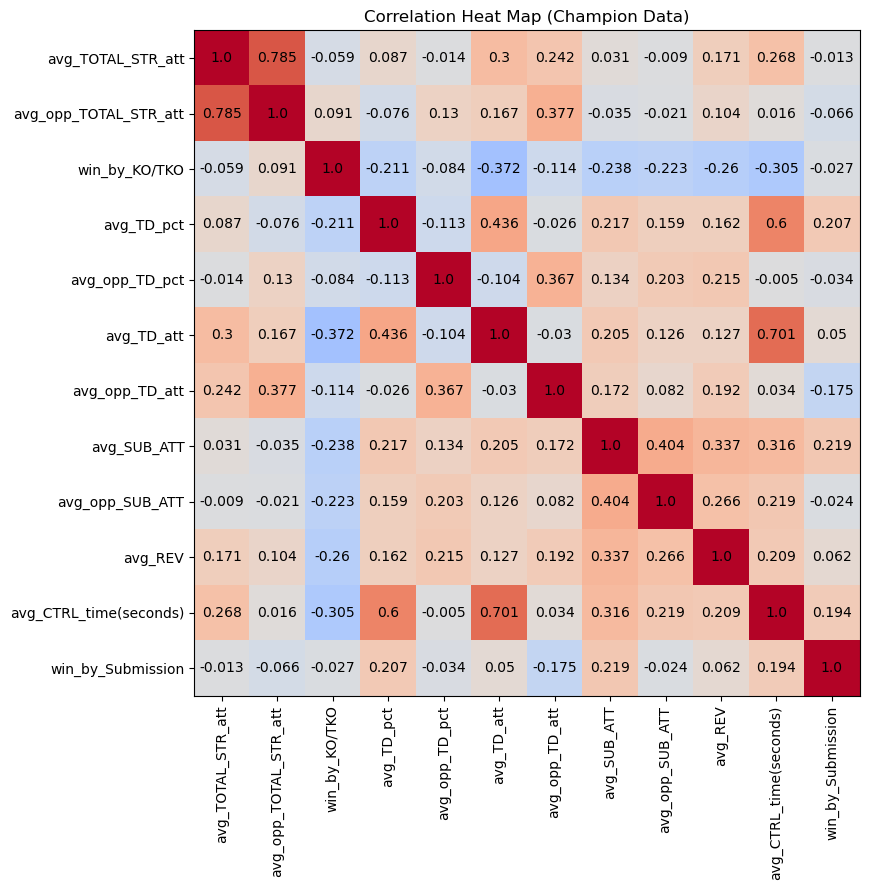

In [516]:
champ_curious_df = combined_champs_df[[
    "avg_TOTAL_STR_att", 
    "avg_opp_TOTAL_STR_att",
    "win_by_KO/TKO",
    "avg_TD_pct",
    "avg_opp_TD_pct",
    "avg_TD_att",
    "avg_opp_TD_att",
    "avg_SUB_ATT",
    "avg_opp_SUB_ATT",
    "avg_REV",
    "avg_CTRL_time(seconds)",
    "win_by_Submission"
]]

champ_corr_matrix = champ_curious_df.corr(numeric_only=True)
champ_corr_matrix = champ_corr_matrix.round(3)
display(champ_corr_matrix)



fig_champ, ax_champ = plt.subplots(figsize=(9,9))

hm_champ = ax_champ.imshow(champ_corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)
ax_champ.set_xticks(range(len(champ_corr_matrix.columns)), labels=champ_corr_matrix.columns, rotation=90)
ax_champ.set_yticks(range(len(champ_corr_matrix.columns)), labels=champ_corr_matrix.columns)
ax_champ.set_title("Correlation Heat Map (Champion Data)")

for i in range(len(champ_corr_matrix)):
    for j in range(len(champ_corr_matrix.columns)):
        champ_text = ax_champ.text(j, i, champ_corr_matrix.values[i, j], ha="center", va="center")

fig_champ.tight_layout()

Notes:
* can see that the correlation between these columns are slightly increased than before:
    * avg_opp_TOTAL_STR_att, avg_TOTAL_STR_att
    * avg_CTRL_time(seconds), avg_TD_pct
    * avg_CTRL_time(seconds), avg_TD_att
* overall, it seems that many correlation values have increased compared to the non champion data
* However, I am not seeing an extremely large difference

The columns are in the same order.
Champion Outlier Count:  {'avg_TOTAL_STR_att': 5, 'avg_opp_TOTAL_STR_att': 5, 'win_by_KO/TKO': 0, 'avg_TD_pct': 1, 'avg_opp_TD_pct': 2, 'avg_TD_att': 0, 'avg_opp_TD_att': 9, 'avg_SUB_ATT': 15, 'avg_opp_SUB_ATT': 10, 'avg_REV': 18, 'avg_CTRL_time(seconds)': 6, 'win_by_Submission': 4}
Non Champion Outlier Count:  {'avg_TOTAL_STR_att': 17, 'avg_opp_TOTAL_STR_att': 21, 'win_by_KO/TKO': 162, 'avg_TD_pct': 27, 'avg_opp_TD_pct': 0, 'avg_TD_att': 40, 'avg_opp_TD_att': 48, 'avg_SUB_ATT': 78, 'avg_opp_SUB_ATT': 81, 'avg_REV': 186, 'avg_CTRL_time(seconds)': 38, 'win_by_Submission': 96}


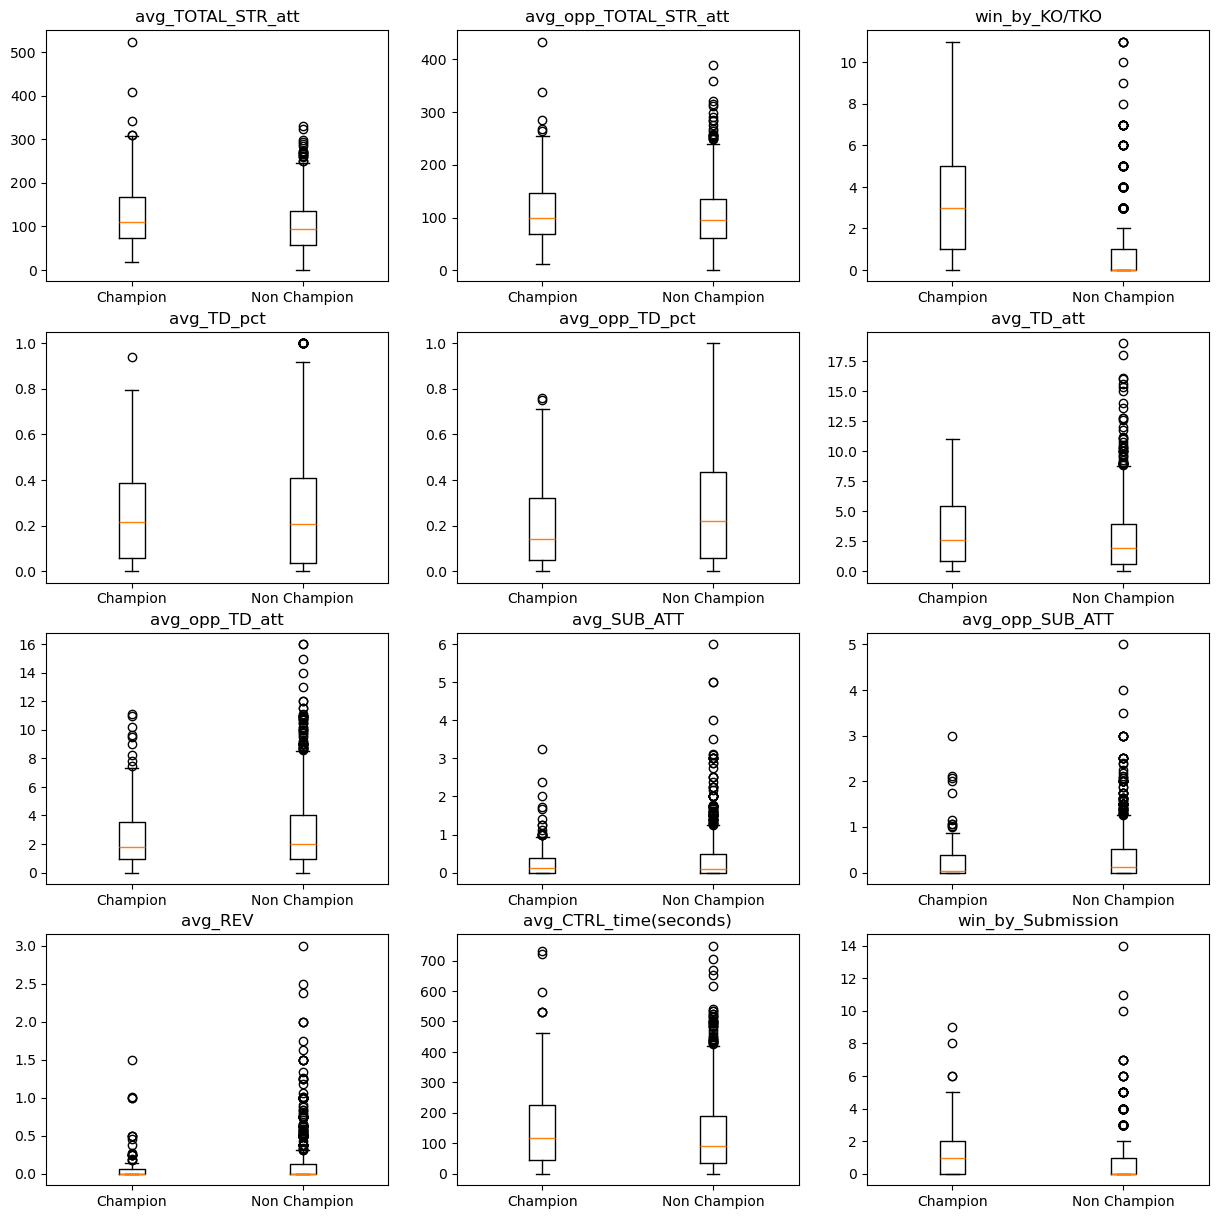

In [517]:
if champ_curious_df.columns.equals(no_champ_curious_df.columns):
    print("The columns are in the same order.")



fig_box, ax_box = plt.subplots(4, 3, figsize=(15,15))

champ_outlier_dict = {}
nonchamp_outlier_dict = {}
for subplot, champ_cols, non_champ_cols in zip(ax_box.flat, champ_curious_df.columns, no_champ_curious_df.columns):
    bp = subplot.boxplot([champ_curious_df[champ_cols], no_champ_curious_df[non_champ_cols]])
    subplot.set_xticklabels(["Champion", "Non Champion"])
    subplot.set_title(champ_cols)

    champ_outlier_dict[champ_cols] = len(bp['fliers'][0].get_ydata())           # adding number of outliers for champion cols
    nonchamp_outlier_dict[non_champ_cols] = len(bp['fliers'][1].get_ydata())    # adding number of outliers for non champion cols

print("Champion Outlier Count: ", champ_outlier_dict)
print("Non Champion Outlier Count: ", nonchamp_outlier_dict)

General Note: 
- it makes sense for non champion data to have more outliers because there is around 10x more rows.
- Outliers for all columns seem to be above the box
    - Most likely implying that the values for most columns are very low
- most boxplots are demonstrating non normal data I think
- going to only mention boxplots that seem very unusual in the notes below (except for avg_TOTAL_STR_att)

Notes:
* avg_TOTAL_STR_att: 
    * Outlier Count:
        * 5/127 for champions 
        * 17/1216 for non champions
    * The median and the spread of points (excluding the outliers) seem to be similar for champions and non champions
* win_by_KO/TKO:
    * Outlier Count:
        * 0/127
        * 162/1216
    * can see that there are no visible outliers for the champion data but there are a significant number of outliers for the non champion data (more than 10% of the column)
        * most likely due to the fact that there are a lot of fighters (who were never champions) that only have a few fights in the UFC
    * It is difficult to see the bottom half of the boxplot for the non champion data which demonstrates that the median is 0 or close to 0
    * I think that this will definitely be one of the cols to be significantly different when comparing champions to non champions (might be too obvious of a statistic)
* avg_TD_att:
    * Outlier Count:
        * 0/127
        * 40/1216
    * boxplots seem pretty similar overall except for the outliers
* avg_SUB_ATT, avg_opp_SUB_ATT, avg_REV:
    * something interesting we can see here is that there are a significant number of outliers for all 3 of these columns
    * additionally, something we can assume is that submissions are difficult to even attempt because the median for both avg_SUB_ATT and avg_opp_SUB_ATT are very close to 0 (for both champion and non champion)
    * similar to submission attempts, reversals seem to be extremely difficult to successfully do based on the median being 0 or close to 0
* win_by_Submission:
    * Outlier Count:
        * 4/127 (3.15%)
        * 96/1216 (7.89%)
    * Around double the number of outliers when comparing percentages
    * While both column data seems to be skewed, the non champion data seems to be significantly more skewed towards the 0 value
        * going back to the thought on difficulty of submissions, the median for both champion and non champion data for this column is close to 0
        * supports the idea that submissions are extremely difficult to attempt and successfully do 


In [518]:
champ_p_val_dict = {}
nonchamp_p_val_dict = {}

for col in champ_curious_df.columns.tolist():
    champ_test_stat, champ_p = shapiro(champ_curious_df[col])
    nonchamp_test_stat, nonchamp_p = shapiro(no_champ_curious_df[col])

    champ_p_val_dict[col + " p-value"] = champ_p
    nonchamp_p_val_dict[col + " p-value"] = nonchamp_p
    
    if champ_p > 0.05:
        print("Can't reject null. ", col, " (champion data) probably follows normal distribution.")
    else: 
        print("Reject null. ", col, " (champion data) probably doesn't follow normal distribution.")

    if nonchamp_p > 0.05:
        print("Can't reject null. ", col, " (nonchampion data) probably follows normal distribution.")
    else: 
        print("Reject null. ", col, " (nonchampion data) probably doesn't follow normal distribution.")


print(champ_p_val_dict)
print(nonchamp_p_val_dict)

Reject null.  avg_TOTAL_STR_att  (champion data) probably doesn't follow normal distribution.
Reject null.  avg_TOTAL_STR_att  (nonchampion data) probably doesn't follow normal distribution.
Reject null.  avg_opp_TOTAL_STR_att  (champion data) probably doesn't follow normal distribution.
Reject null.  avg_opp_TOTAL_STR_att  (nonchampion data) probably doesn't follow normal distribution.
Reject null.  win_by_KO/TKO  (champion data) probably doesn't follow normal distribution.
Reject null.  win_by_KO/TKO  (nonchampion data) probably doesn't follow normal distribution.
Reject null.  avg_TD_pct  (champion data) probably doesn't follow normal distribution.
Reject null.  avg_TD_pct  (nonchampion data) probably doesn't follow normal distribution.
Reject null.  avg_opp_TD_pct  (champion data) probably doesn't follow normal distribution.
Reject null.  avg_opp_TD_pct  (nonchampion data) probably doesn't follow normal distribution.
Reject null.  avg_TD_att  (champion data) probably doesn't follow

In [519]:
# Testing for equal variance through the Levene's test.
# Null Hypothesis: the two groups have equal variance.
for col in champ_curious_df.columns:
    lev_stat, lev_p = levene(champ_curious_df[col], no_champ_curious_df[col])
    
    if lev_p > 0.05:
        # ddof=1 makes it so sample variance is being calculated and not population variance
        print("Champ " + col + " Variance: ", np.var(champ_curious_df[col], ddof=1))
        print("Non Champ " + col + " Variance: ", np.var(no_champ_curious_df[col], ddof=1))
        print(col + " p-value: ", lev_p)
        print(col + ": Equal variance.\n")
    else:
        print("Champ " + col + " Variance: ", np.var(champ_curious_df[col], ddof=1))
        print("Non Champ " + col + " Variance: ", np.var(no_champ_curious_df[col], ddof=1))
        print(col + " p-value: ", lev_p)
        print(col + ": Not equal variance.\n")

Champ avg_TOTAL_STR_att Variance:  6511.711600276258
Non Champ avg_TOTAL_STR_att Variance:  3139.485291796239
avg_TOTAL_STR_att p-value:  0.000451022247302846
avg_TOTAL_STR_att: Not equal variance.

Champ avg_opp_TOTAL_STR_att Variance:  4702.360229164644
Non Champ avg_opp_TOTAL_STR_att Variance:  3050.206283949509
avg_opp_TOTAL_STR_att p-value:  0.04984964691764132
avg_opp_TOTAL_STR_att: Not equal variance.

Champ win_by_KO/TKO Variance:  7.785901762279713
Non Champ win_by_KO/TKO Variance:  2.5227846816114434
win_by_KO/TKO p-value:  4.31890079588097e-14
win_by_KO/TKO: Not equal variance.

Champ avg_TD_pct Variance:  0.04780122685968559
Non Champ avg_TD_pct Variance:  0.05880846863586162
avg_TD_pct p-value:  0.20485252054695738
avg_TD_pct: Equal variance.

Champ avg_opp_TD_pct Variance:  0.03942054409502265
Non Champ avg_opp_TD_pct Variance:  0.06260721019437719
avg_opp_TD_pct p-value:  0.0014797675221265804
avg_opp_TD_pct: Not equal variance.

Champ avg_TD_att Variance:  7.45685103559

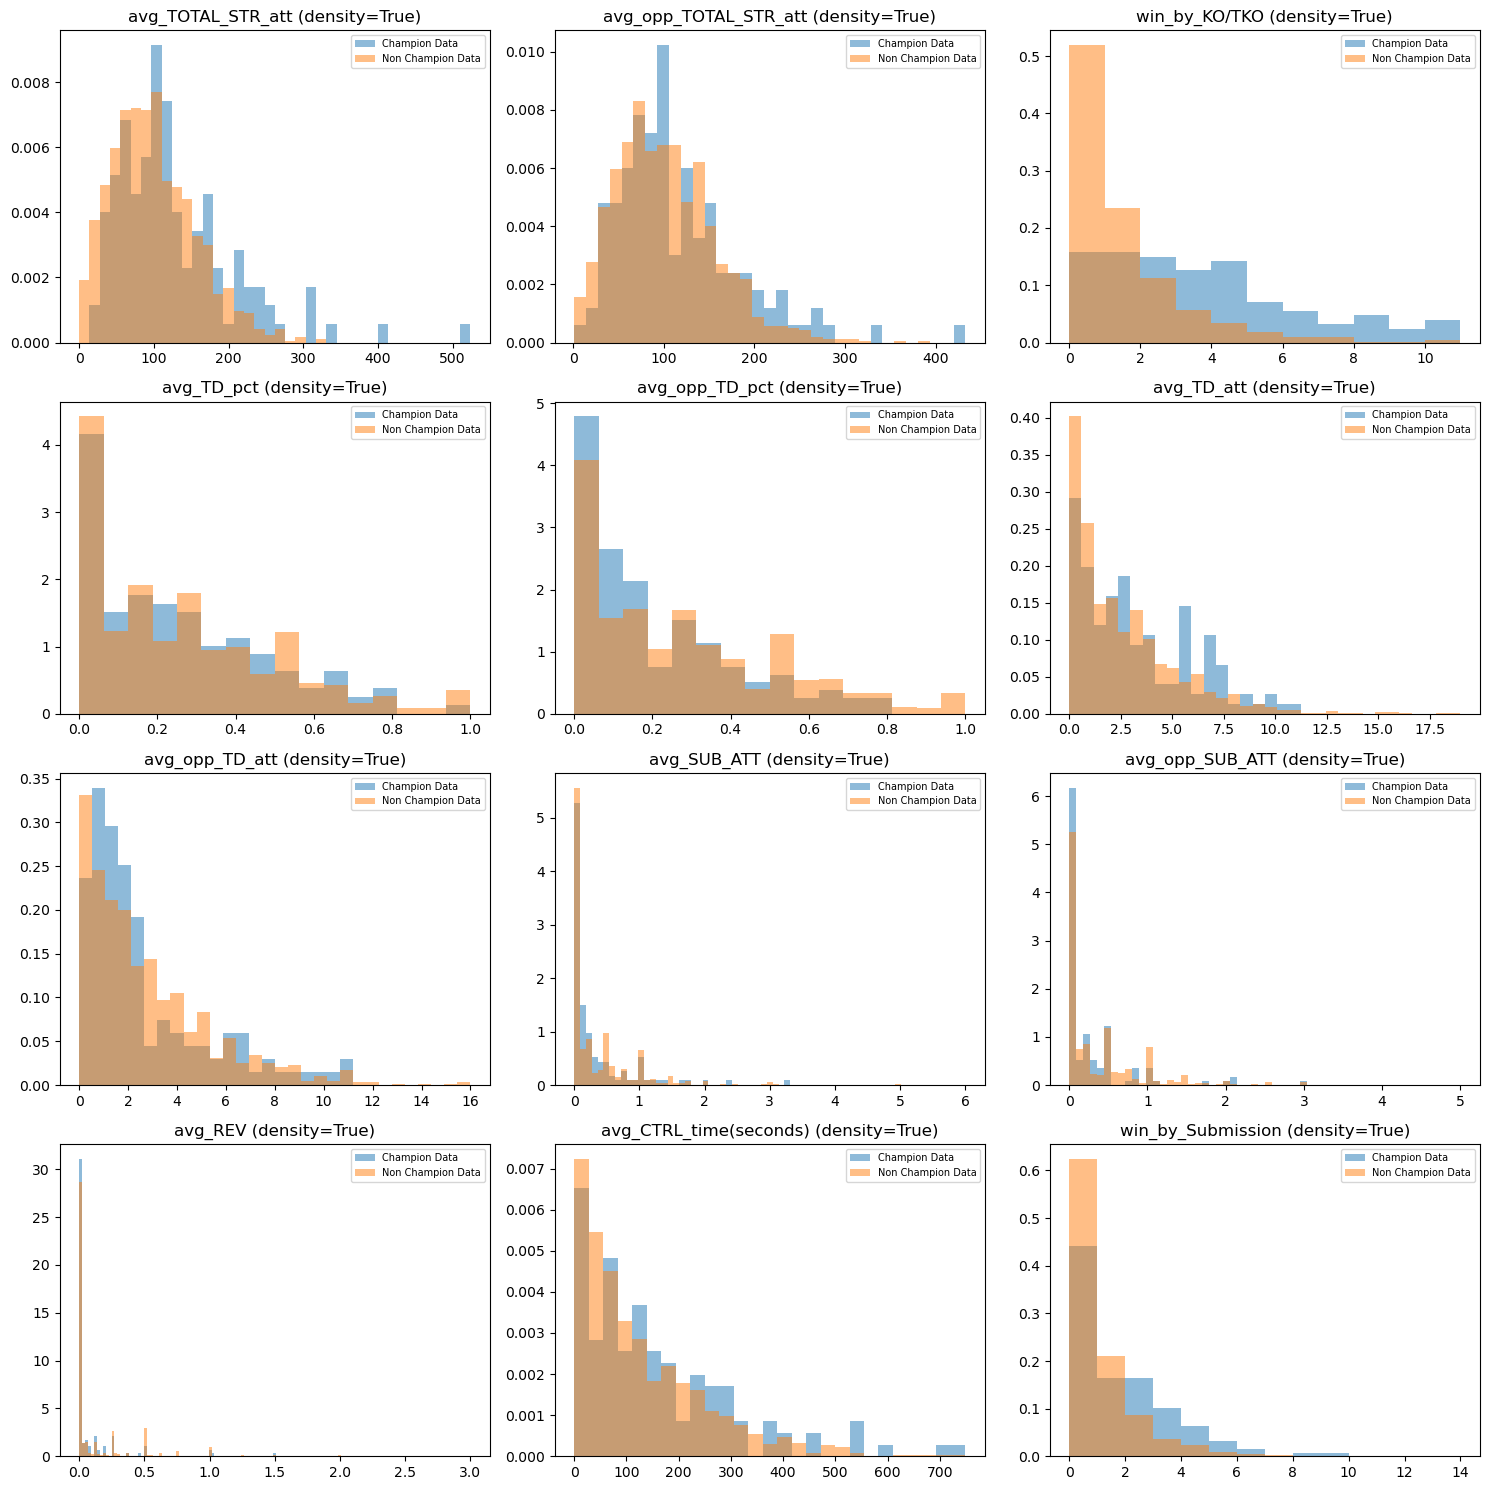

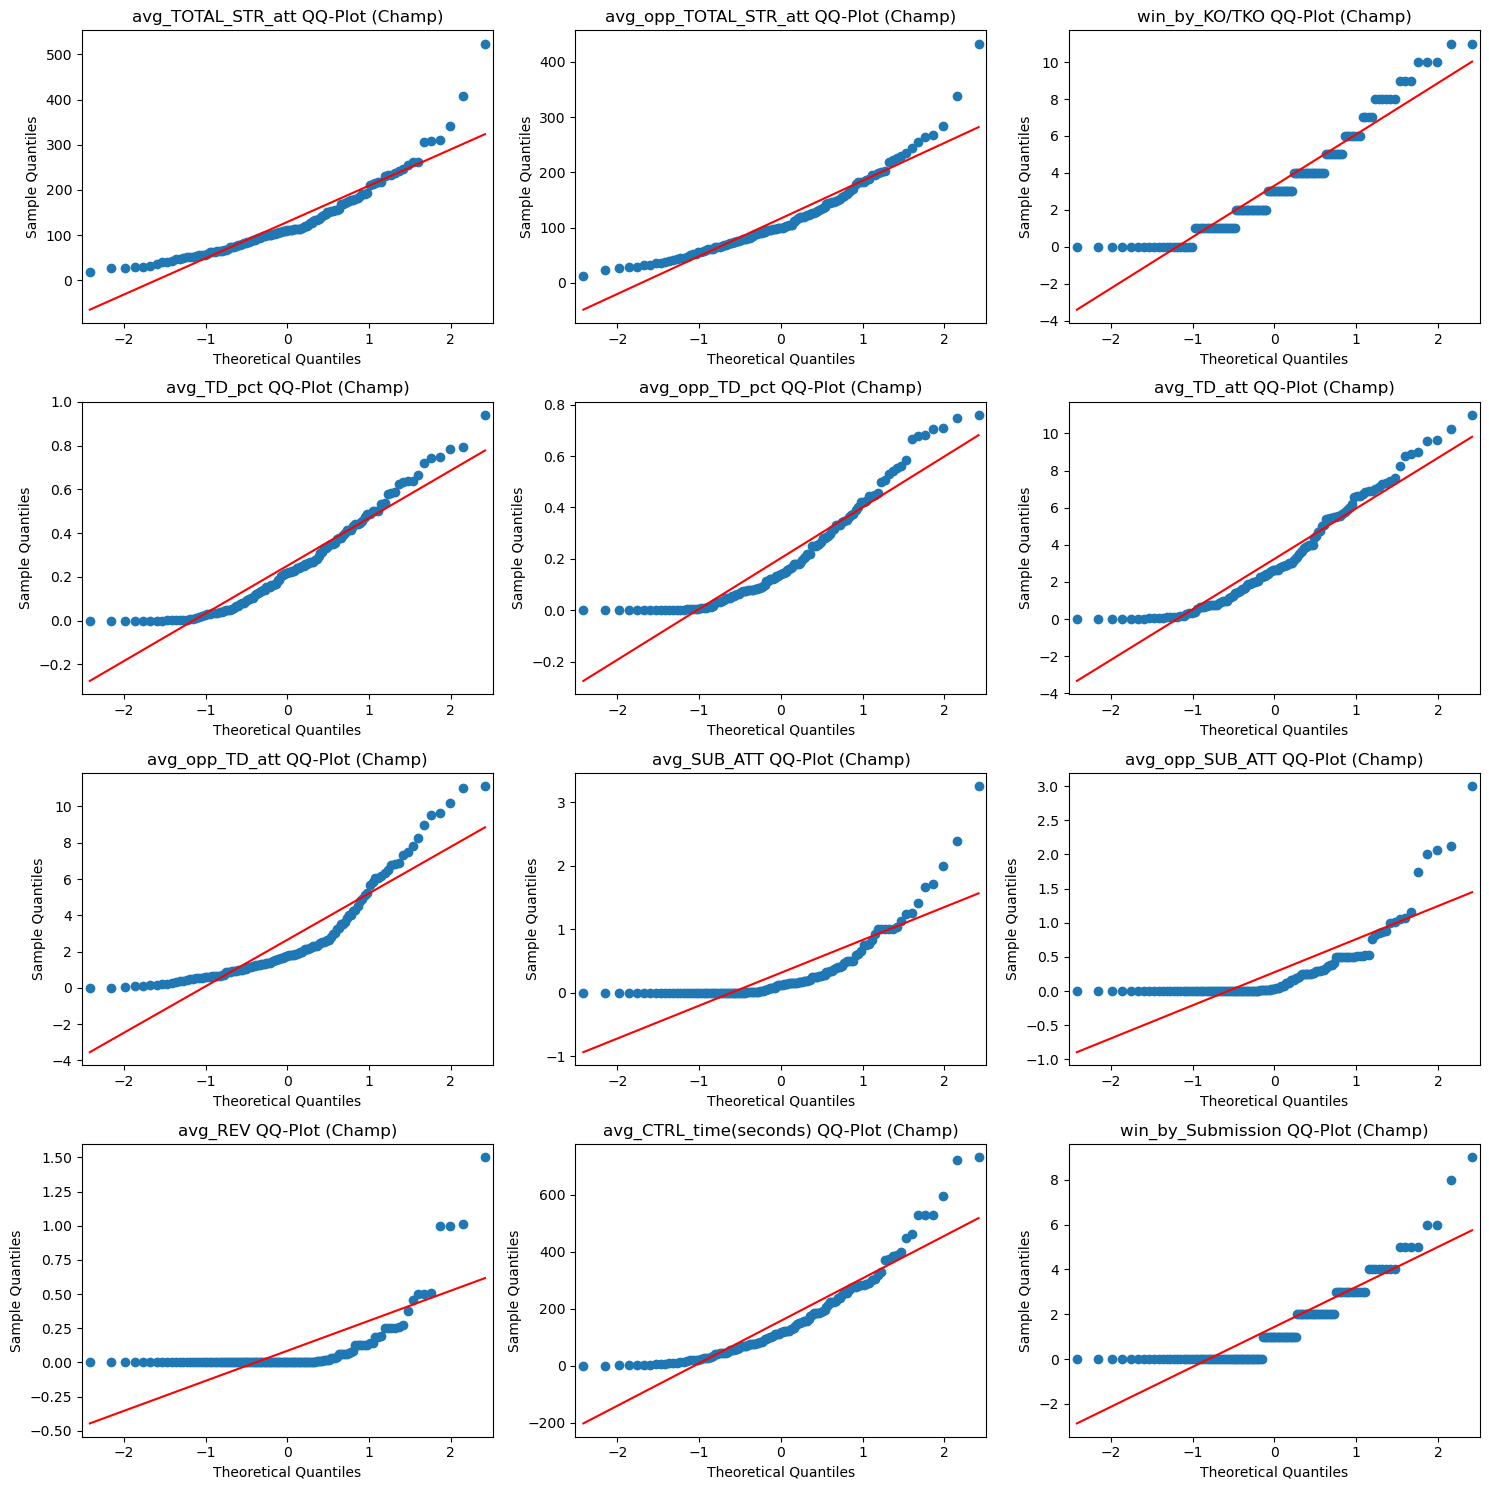

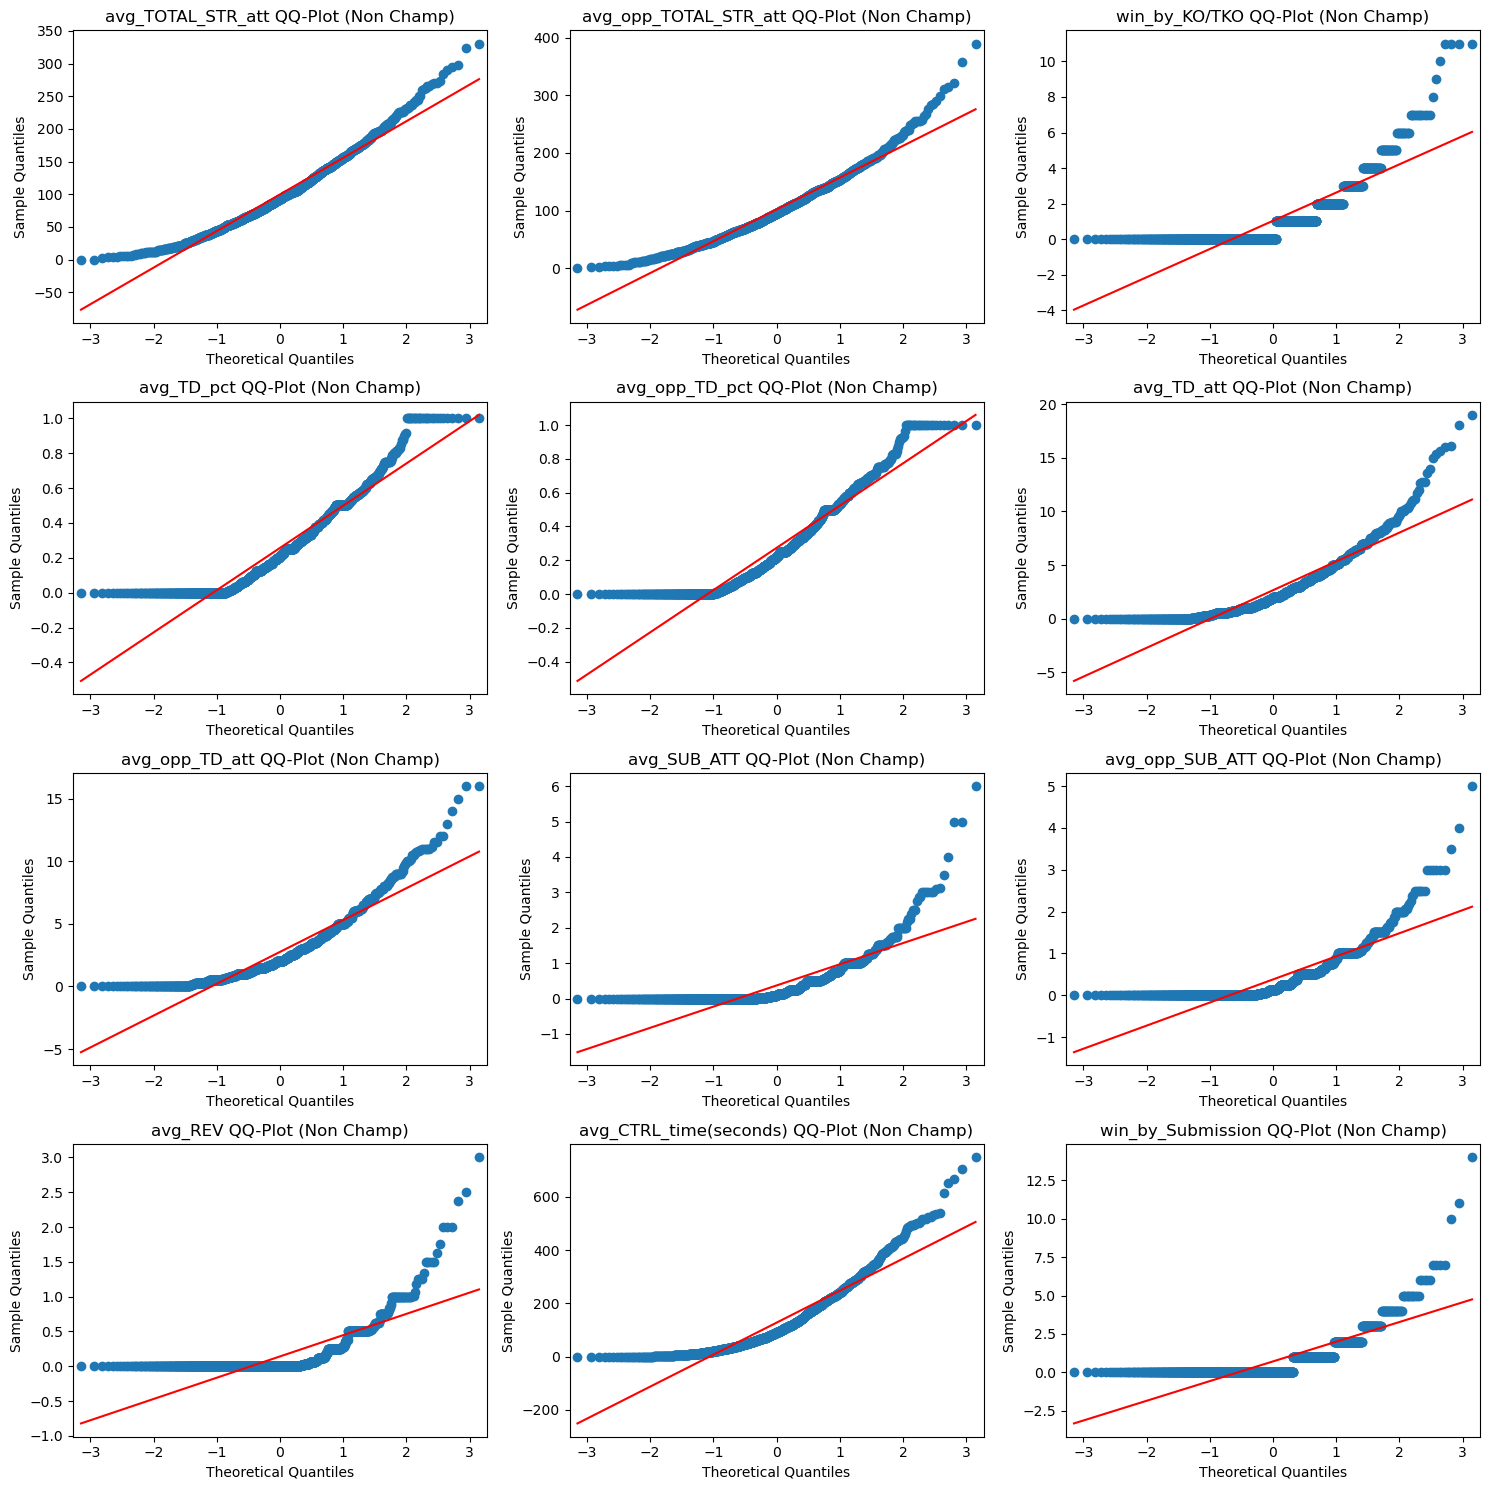

In [520]:
hist_fig, hist_ax = plt.subplots(4, 3, figsize=(15,15))

for subplot, cols in zip(hist_ax.flat, champ_curious_df.columns):
    # Combining the data from champion and nonchampion dfs to create combined bins.
    # This prevents having different bins for the same histogram.
    # If bins were different, it would be difficult to see the distribution.
    comb_bin = np.histogram_bin_edges(pd.concat([champ_curious_df[cols], no_champ_curious_df[cols]]), bins="auto")

    # Set density=True because the non champion data has 10x more rows so if the histograms were to be plotted on top of each other,
    # it would prevent seeing the champion data clearly because the y-axis would be scaled to the non champion row count.
    subplot.hist(champ_curious_df[cols], bins=comb_bin, alpha=0.5, density=True, label="Champion Data")
    subplot.hist(no_champ_curious_df[cols], bins=comb_bin, alpha=0.5, density=True, label="Non Champion Data")
    subplot.set_title(cols + " (density=True)")
    subplot.legend(fontsize=7)

hist_fig.tight_layout()



champ_qq_fig, champ_qq_ax = plt.subplots(4, 3, figsize=(15,15))

for subplot, col in zip(champ_qq_ax.flat, champ_curious_df.columns):
    sm.qqplot(champ_curious_df[col], line='s', ax=subplot)
    subplot.set_title(col + " QQ-Plot (Champ)")

champ_qq_fig.tight_layout()


nonchamp_qq_fig, nonchamp_qq_ax = plt.subplots(4, 3, figsize=(15,15))

for subplot, col in zip(nonchamp_qq_ax.flat, no_champ_curious_df.columns):
    sm.qqplot(no_champ_curious_df[col], line='s', ax=subplot)
    subplot.set_title(col + " QQ-Plot (Non Champ)")

nonchamp_qq_fig.tight_layout()

Notes: 
* Although Shapiro Wilk test isn't 100% accurate due to sample size, you can see that the null hypothesis is rejected in every single test
    * This would mean that the Shapiro Wilk test believes all columns do not follow a normal distribution
* Many of the boxplots support these outputs as mentioned previously about how the data is skewed
    * almost all histograms support this as well
    * MAYBE avg_TOTAL_STR_att and avg_opp_TOTAL_STR_att could follow normal distribution (not sure)
* QQ-plots made for additional confirmation
    * can clearly see that data doesn't follow a normal distribution
* Levene's test demonstrates that 5/12 columns have equal variance and 7/12 doesn't
    * this would mean a regular t-test would be difficult to do bc it assumes equal variance
    * Welch's t-test could work with non equal variance but data is still non normal
* So, how am I going to do a hypothesis test with non normal data and non equal variance?
    * Boostrap Confidence Intervals

In [521]:
# Here, need to create a function for the "statistic" parameter for Bootstrapping.
# Because most of the data is pretty skewed, it may be better to use median instead of mean.
# Mean might not be the most accurate because all of the outliers (skewed data in general) can lead to misrepresentation of the two samples.
# For example, maybe 100 fighters, on average, strike 100 times but due to 10 fighters striking 1000 times, the mean is a significantly
# large value. 
def median(group1, group2, axis=-1):
    group1_median = np.median(group1, axis=axis)
    group2_median = np.median(group2, axis=axis)
    return group1_median - group2_median

In [522]:
median_diff_cols = []
median_no_diff_cols = []

for col in champ_curious_df.columns:
    bootstrap_data = [champ_curious_df[col], no_champ_curious_df[col]]
    # rng=np.random.default_rng(1) -> this is the seed. Makes sure that the samples will be the same everytime.
    bootstrap_dist = bootstrap(bootstrap_data, median, method="Basic", rng=np.random.default_rng(1))
    print(col + ": ", bootstrap_dist.confidence_interval)

    if bootstrap_dist.confidence_interval.low < 0 < bootstrap_dist.confidence_interval.high:
        print("0 is within the bootstrap confidence intervals.\n" \
        "Therefore, there is not enough evidence to say that the median for " + col + " is significantly different between champions "
        "and non champions.\n")
        median_no_diff_cols.append(col)
    else:
        print("0 is not within the bootstrap confidence intervals.\n" \
        "Therefore, the null hypothesis can be rejected, meaning that there is a signficant difference in the median between champions and "
        "non champions for " + col + ".\n")
        median_diff_cols.append(col)

print("No Difference (Median): ", median_no_diff_cols)
print("Significant Difference (Median): ", median_diff_cols)

avg_TOTAL_STR_att:  ConfidenceInterval(low=np.float64(7.557339102588596), high=np.float64(27.504606342315686))
0 is not within the bootstrap confidence intervals.
Therefore, the null hypothesis can be rejected, meaning that there is a signficant difference in the median between champions and non champions for avg_TOTAL_STR_att.

avg_opp_TOTAL_STR_att:  ConfidenceInterval(low=np.float64(-13.585182875394793), high=np.float64(13.333477115631128))
0 is within the bootstrap confidence intervals.
Therefore, there is not enough evidence to say that the median for avg_opp_TOTAL_STR_att is significantly different between champions and non champions.

win_by_KO/TKO:  ConfidenceInterval(low=np.float64(3.0), high=np.float64(4.0))
0 is not within the bootstrap confidence intervals.
Therefore, the null hypothesis can be rejected, meaning that there is a signficant difference in the median between champions and non champions for win_by_KO/TKO.

avg_TD_pct:  ConfidenceInterval(low=np.float64(-0.033828